In [3]:
import pandas as pd
import numpy as np
import math as mt
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import *
import chardet
import datetime

In [4]:
data_players = pd.read_csv('data_players.csv')
data_match_scores = pd.read_csv('match_scores.csv')
data_match_stats = pd.read_csv('match_stats.csv')
data_rankings_1 = pd.read_csv('rankings.csv')
data_rankings_2=pd.read_csv('rankings_2.csv')
data_rankings_3=pd.read_csv('rankings_3.csv')
data_rankings=pd.concat([data_rankings_1,data_rankings_2,data_rankings_3])
annee_debut=1960
diametre_balle=6.5
players_non_retraites=data_players.birth_year>=annee_debut
players_taille_ok=data_players.height_cm>diametre_balle
data_players_choisis=data_players[players_non_retraites & players_taille_ok]

160.0 220.0
[160. 165. 170. 175. 180. 185. 190. 195. 200. 205. 210. 215.]


(array([  1.,  13., 103., 342., 657., 626., 364.,  90.,  20.,   2.,   2.]),
 array([160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210.,
        215.]),
 <BarContainer object of 11 artists>)

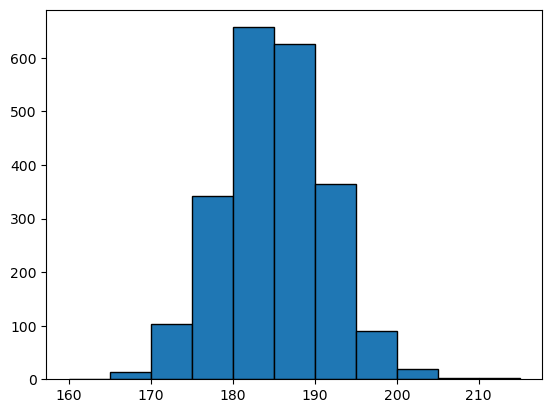

In [28]:
###HISTOGRAMME TAILLES
annee_debut=1960
tailles = data_players_choisis["height_cm"]
xmingraph = np.floor(tailles.min()/5)*5
xmaxgraph = np.floor(tailles.max()/5)*5+5*2
print(xmingraph,xmaxgraph)
liste_bornes=np.arange(xmingraph,xmaxgraph,5)
print(liste_bornes)
plt.hist(data_players_choisis["height_cm"],bins=liste_bornes,ec="black")



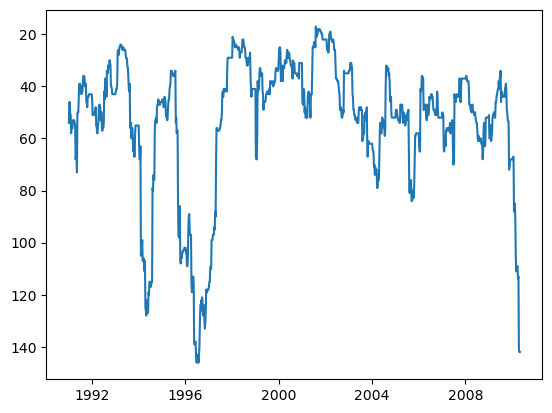

In [40]:
###Graphique évolution classement
joueur_voulu='s424'


datavoulue = data_rankings.loc[(data_rankings["player_id"]==joueur_voulu)]

datavoulue = datavoulue.sort_values(by="week_title")
x_graph=np.char.replace(datavoulue.week_title.values.astype('str'),'.','-').astype('datetime64')
plt.gca().invert_yaxis()
plt.plot(x_graph,datavoulue["rank_number"])
#Pour avoir son vecteur de données en abscisses après avoir trié selon week_title pour obtenir dates:
#x_graph=np.char.replace(dates.values.astype('str'),'.','-').astype('datetime64')

In [ ]:
###CORRELATION TAILLE/ TAUX POINTS GAGNES APRES PREMIERS SERVICES REUSSIS


#A la fin pour ne pas exclure de la représentation les joueurs qui n'auraient rien gagné par exemple :
#stats_matchs_par_joueur=stats_matchs_par_joueur.fillna(0)